# Neural Networks

### Notebook created by Keshav Sriram Kumar
By the end of this lesson you would have covered various concepts of Neural Networks.

## Overview
- Perceptrons
- Coding a Perceptron
- Number Example
- <span style="color:red;">Tensor Flow</span>

## Tensor Flow

We need to start by upgrading our pip installer, then installing Tensor Flow.   These are currently commented out.  You only need to do this once so once you have run the pip install you can comment these commands out.

In [1]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


Keras contains a number of datasets that we can download and use.<br>
https://keras.io/api/datasets/

In [3]:
import tensorflow as ts
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

The mnist dataset contains a set of images of numbers that we are going to train.  We can load it as a training and testing set.

In [4]:
import tensorflow.keras as tk
mnist = tk.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


We are going to identify a set of labels for our images, and see what they look like.

In [5]:
labels=['0','1','2','3','4','5','6','7','8','9']

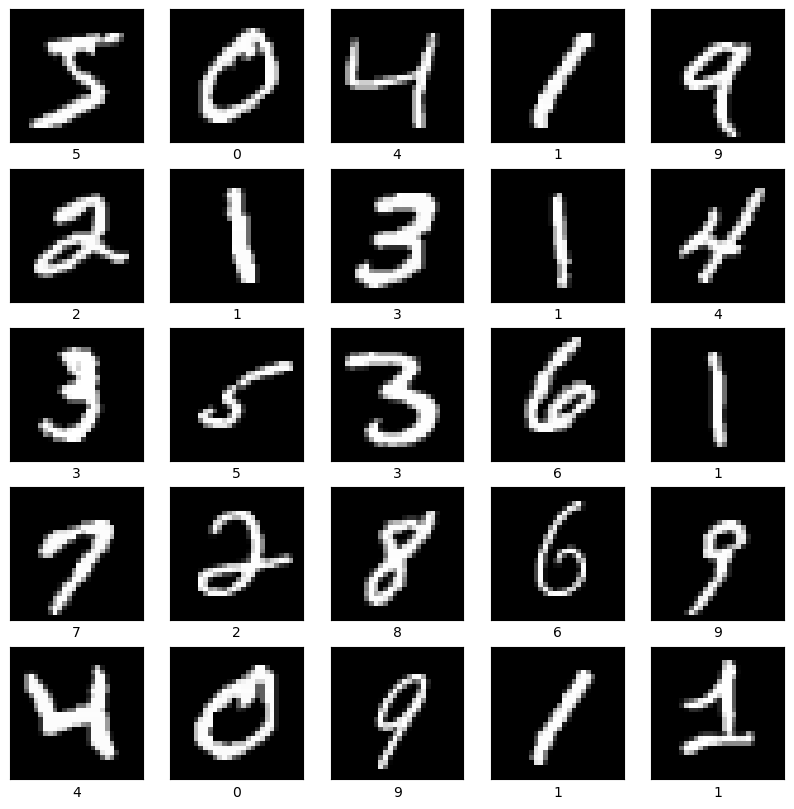

In [6]:
#There are 6000 images, we are only going to see what the first 25 look like
plt.figure(figsize=(10,10))
for i in range(25): 
  plt.subplot(5,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(train_images[i],cmap='grey')
  plt.xlabel(labels[train_labels[i]])
plt.show()

We now want to build our model.  For the sake of brevity, we are not going to build a complex model.  Our model will contain a convolution layer, and then process it with a neural network.

The convolution layer is commonly used in bluring or sharpening images.  It is an image processing function.  It examines clusters of pixels, contrasting adjacent pixels, and applying a mapping function.  

<div style="max-width:400px;">

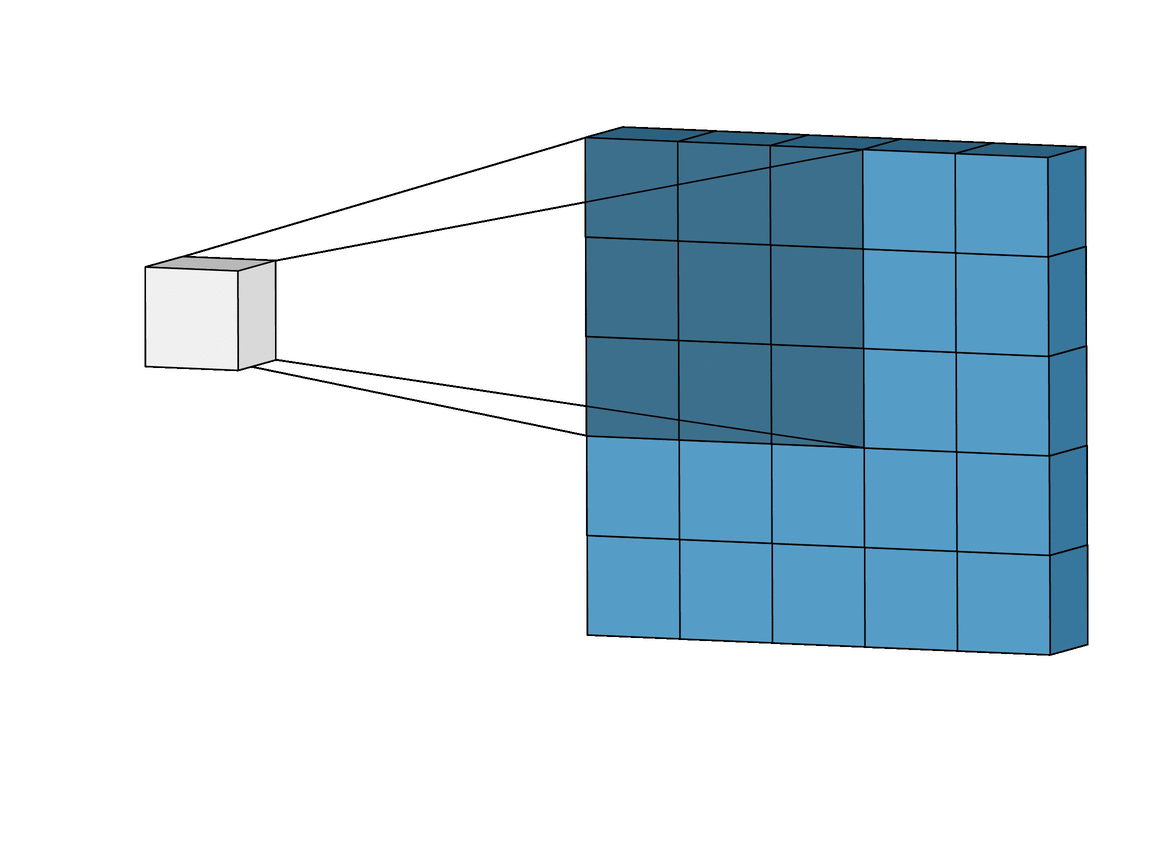

</div>

Source:https://miro.medium.com/v2/resize:fit:1100/format:webp/1*Fw-ehcNBR9byHtho-Rxbtw.gif 

In [7]:
from keras.models import Sequential
from keras.layers import Dense,Conv2D,Flatten

#The reshape identifies (# of images, and our input shape)
x_train=train_images.reshape(60000,28,28,1)
x_test=test_images.reshape(10000,28,28,1)

model=Sequential()
#We add a series of convolution layers to our model.  
# (Number of filters, kernel size (The size of the area being analyzed(width, height)), activation layer of our node, input_shape)
#Convolution is commonly used in bluring or sharpening images.
#It is an image processing function.  It examines clusters of pixels, contrasting adjacent pixels.  
model.add(Conv2D(128,(2,2),activation='relu',input_shape=(28,28,1)))
model.add(Conv2D(64,(2,2),activation='relu',input_shape=(28,28,1)))
model.add(Conv2D(32,(2,2),activation='relu',input_shape=(28,28,1)))
model.add(Conv2D(16,(2,2),activation='relu',input_shape=(28,28,1)))
#Convert output of previous layers into a 1D representation.
model.add(Flatten())
#The dense layer builds our nerual network where it connects each node of our prevous layers to the node.
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
#The last layer of our dense layer will be our possible outputs.  Since we have 10 possibilities we will have 10 here.
model.add(Dense(10,activation='softmax'))
#Optimizer - we have a choice of a few to use here https://keras.io/api/optimizers/
#Loss - https://keras.io/api/losses/
model.compile(optimizer='Adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

c:\Users\kesha\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
#Now we want to train.  The more epochs we assign the longer our model will train.
model.fit(x_train,train_labels,epochs=5,validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 180s 102ms/step - accuracy: 0.9524 - loss: 0.1637 - val_accuracy: 0.9788 - val_loss: 0.0838
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 169s 100ms/step - accuracy: 0.9816 - loss: 0.0605 - val_accuracy: 0.9822 - val_loss: 0.0619
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 166s 98ms/step - accuracy: 0.9875 - loss: 0.0398 - val_accuracy: 0.9817 - val_loss: 0.0637
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 162s 96ms/step - accuracy: 0.9914 - loss: 0.0266 - val_accuracy: 0.9852 - val_loss: 0.0595
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 169s 100ms/step - accuracy: 0.9933 - loss: 0.0225 - val_accuracy: 0.9847 - val_loss: 0.0661


Let's check the accuracy of our model.

In [9]:
from sklearn.metrics import classification_report
predictions = model.predict(x_test)
print(classification_report(test_labels,predictions.argmax(axis=1)))

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.98      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.99      0.98      0.99      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.98      0.98       892
           6       0.98      0.99      0.98       958
           7       0.96      0.99      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



Looks good.  We now want to test it with our own image.  I have attached an image of a number I drew in paint.  If you want to use your own image, feel free to edit the image.

You will need to install opencv

In [12]:
pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ----- ---------------------------------- 6.0/40.2 MB 29.0 MB/s eta 0:00:02
   ---------- ----------------------------- 10.5/40.2 MB 24.2 MB/s eta 0:00:02
   ------------- -------------------------- 13.6/40.2 MB 25.2 MB/s eta 0:00:02
   -------------- ------------------------- 14.2/40.2 MB 16.6 MB/s eta 0:00:02
   -------------- ------------------------- 14.7/40.2 MB 13.7 MB/s eta 0:00:02
   ---------------------- ----------------- 22.3/40.2 MB 17.0 MB/s eta 0:00:02
   ------------------------------ --------- 30.9/40.2 MB 20.2 MB/s eta 0:00:01
   ---------------------------------------  39.3/40.2 MB 22.5 MB/s eta 0:00:01
   ---------------------------------------  40.1/40.2 MB 22.7 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 18.9 MB/s  0:00:02
Note: you may need to restart the kernel to use updated packages.


In [13]:
import cv2
file = r'mynum.png'
testimg = cv2.imread(file, cv2.IMREAD_GRAYSCALE)

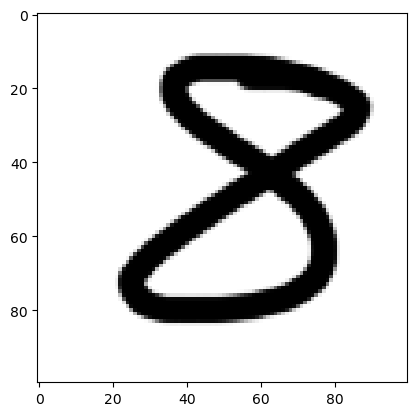

In [14]:
plt.imshow(testimg, cmap='grey')

We need to resize the image so that it can be analyzed with our model.

In [15]:
img_resized = cv2.resize(testimg, (28, 28), interpolation=cv2.INTER_LINEAR)

This image has a white background and black text.  If you look at the images we displayed earlier, we need this reversed for our dataset.

In [16]:
img_resized=cv2.bitwise_not(img_resized)

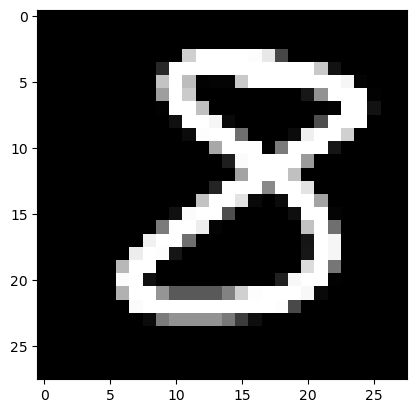

In [17]:
plt.imshow(img_resized, cmap='grey')

We need to setup our image to make a prediction, then test that prediction.

In [18]:
Xt = img_resized.reshape(1,28,28,1)
model.predict(Xt)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


array([[1.0706685e-04, 1.2838806e-03, 6.4886741e-02, 4.4189412e-03,
        9.9976271e-05, 1.1347892e-04, 1.4165170e-03, 1.6205790e-04,
        9.2724949e-01, 2.6186401e-04]], dtype=float32)

So what does this mean?  We have 10 possible outputs in our neural network.  Based on the image we gave it, these are the probabilities for each output.  If we pick the max value:

In [19]:
print(model.predict(Xt).argmax())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
8


References:
https://www.kaggle.com/datasets/zalando-research/fashionmnist and several of the posts and responses related to it.